### Read individual .csv files with predictions and store as one single .csv

In [ ]:
import os
from pathlib import Path
import glob
import sys
import time
from datetime import datetime
import pandas as pd
import numpy as np
from obspy import read
import numpy as np
import matplotlib.pyplot as plt

# Path for .mseed data
data_dir = "../data/waveforms_noise_only"

# Base path: where to gather the outputs from
# csv output path: where to store the combined csv
base_path = "../results/csv/" 
subdir = "/bm_noise_only"

csv_output_path = os.path.join(base_path, "combined")
csv_output_name = subdir + "_full.csv"

# Match filenames to only get the csv outputs
files = list(Path(base_path + subdir).rglob("*.csv"))

# Sort files by timechunk folder name (0 = station, 1 = timechunk)
files = sorted(files, key=lambda x:x.parents[1].name)

# Load into single df
df = pd.concat((pd.read_csv(file) for file in files), ignore_index=True)

# Keep only rows with predictions
pred_cols = ["p_probability", "s_probability"]
df = df[df[pred_cols].notna().any(axis=1)]

# Extract raw datetime string from time window directories
pattern = r"(?P<station>[^/]+)/(?P<network>[^.]+)\.(?P=station)\.\.(?P<channel>[A-Z]{3})__(?P<start_dt>\d{8}T\d{6}Z)__(?P<end_dt>\d{8}T\d{6}Z)\.mseed"
matches = df["file_name"].str.extract(pattern)

# Convert to datetime and insert into dataframe
df["start_dt"] = pd.to_datetime(matches["start_dt"], format="%Y%m%dT%H%M%SZ")
df["end_dt"] = pd.to_datetime(matches["end_dt"], format="%Y%m%dT%H%M%SZ")

# Sort df by window start time
df = df.sort_values(by="start_dt", ascending=True)

# Insert correct network code
df["network"] = matches["network"].str.strip().str.upper()
df["station"] = matches["station"].str.strip().str.upper()

# Filter out rows with NaN for both p_probability and s_probability (no predicted picks)
df = df[df["p_probability"].notna() | df["s_probability"].notna()]

# Save dataframe to csv
os.makedirs(csv_output_path, exist_ok=True)
df.to_csv(csv_output_path + csv_output_name, index=False)

# Print some basic information about the number of predicted picks
num_rows = len(df)
num_files = len(files)
num_p_picks = sum(df["p_probability"].notna())
num_s_picks = sum(df["s_probability"].notna())
num_negatives = sum(df["p_probability"].isna() & df["s_probability"].isna())

print(f"Read {num_rows} rows from {num_files} files.")
print(f"Number of predicted p-arrivals: {num_p_picks}\nNumber of predicted s-arrivals: {num_s_picks}\nTotal number of arrivals: {num_p_picks+num_s_picks}")
print(f"Number of empty predictions: {num_negatives}")

Read 1774 predictions from 2004 files.
Number of predicted p-arrivals: 1773
Number of predicted s-arrivals: 35
Total number of arrivals: 1808
Number of empty predictions: 0


### Plot waveforms and predicted p/s picks

In [10]:
from obspy import read, Stream, UTCDateTime
import glob
import re
from collections import defaultdict

# Index the waveform files
def build_waveform_index(data_dir):

    index = defaultdict(list)

    pattern = re.compile(
        r"(?P<network>[^.]+)\.(?P<station>[^.]+)\.\.(?P<channel>[A-Z0-9]+)__(?P<start>\d{8}T\d{6}Z)__(?P<end>\d{8}T\d{6}Z)\.mseed"
    )

    for root, _, files in os.walk(data_dir):
        for f in files:
            if not f.endswith(".mseed"):
                continue

            m = pattern.match(f)
            if not m:
                continue

            key = (m.group("network"), m.group("station"))
            start = UTCDateTime(m.group("start"))
            end = UTCDateTime(m.group("end"))

            index[key].append((start, end, os.path.join(root, f)))
            
    # Sort list chronologically
    for key in index:
        index[key].sort(key=lambda x: x[0])

    return index


# Load a station-specific time window
def load_station_window(index, network, station, start_dt, end_dt):

    start = UTCDateTime(start_dt)
    end = UTCDateTime(end_dt)

    st = Stream()

    for fstart, fend, path in index[(network, station)]:

        if fend < start or fstart > end:
            continue

        st += read(path)

    if len(st) == 0:
        return st

    st.merge(method=1, fill_value="interpolate")
    st.trim(start, end)

    return st


# Plot a row in the prediction results dataframe
def plot_row(row, index, p_tr=0.01):
    # Channels to plot
    channels = ["HHN", "HHE", "HHZ"]
    # Filter by probability threshold
    if not (
        (pd.notna(row.p_probability) and row.p_probability > p_tr) or
        (pd.notna(row.s_probability) and row.s_probability > p_tr)
    ):
        return

    st = load_station_window(
        index,
        row.network.strip(),
        row.station.strip(),
        row.start_dt,
        row.end_dt
    )

    if len(st) == 0:
        #print("No waveform:", row.station, row.start_dt)
        return

    starttime = st[0].stats.starttime
    endtime = st[0].stats.endtime
    fs = st[0].stats.sampling_rate
    window_length = endtime - starttime

    refP = (
        int((UTCDateTime(row.p_arrival_time) - starttime) * fs)
        if pd.notna(row.p_arrival_time)
        else None
    )

    refS = (
        int((UTCDateTime(row.s_arrival_time) - starttime) * fs)
        if pd.notna(row.s_arrival_time)
        else None
    )

    fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
    fig.suptitle(
        f"{row.network}.{row.station}  {row.start_dt} to {row.end_dt}",
        fontsize=10
    )

    for j, ch in enumerate(channels):

        tr = st.select(channel=ch)
        if len(tr) == 0:
            axes[j].set_ylabel(ch)
            continue

        tr = tr[0].copy()

        tr.detrend("linear")
        tr.detrend("demean")
        tr.taper(0.05)
        tr.filter("bandpass", freqmin=1, freqmax=45, corners=2, zerophase=True)

        axes[j].plot(tr.data, color="grey", linewidth=1)

        y_min, y_max = tr.data.min(), tr.data.max()

        if refP is not None:
            axes[j].vlines(refP, y_min, y_max, color='r', linewidth=2, linestyle="dashed", label=f'P-predicted (p={row.p_probability})')
        if refS is not None:
            axes[j].vlines(refS, y_min, y_max, color='b', linewidth=2, linestyle="dashed", label=f'S-predicted (p={row.s_probability})')

        # Label y-axis (channel)
        axes[j].set_ylabel(ch)
        if refP is not None or refS is not None:
            axes[j].legend(loc='lower right')
    # Label x-axis
    axes[j].set_xlabel(f"Samples ({window_length}s*{fs}Hz)", fontsize=12)
    plt.tight_layout()
    plt.show()

    return True

In [5]:
# Open the .csv file with predictions
df = pd.read_csv(csv_output_path + csv_output_name)

# Index the .mseed files to match predictions with time windows
waveform_idx = build_waveform_index(data_dir)

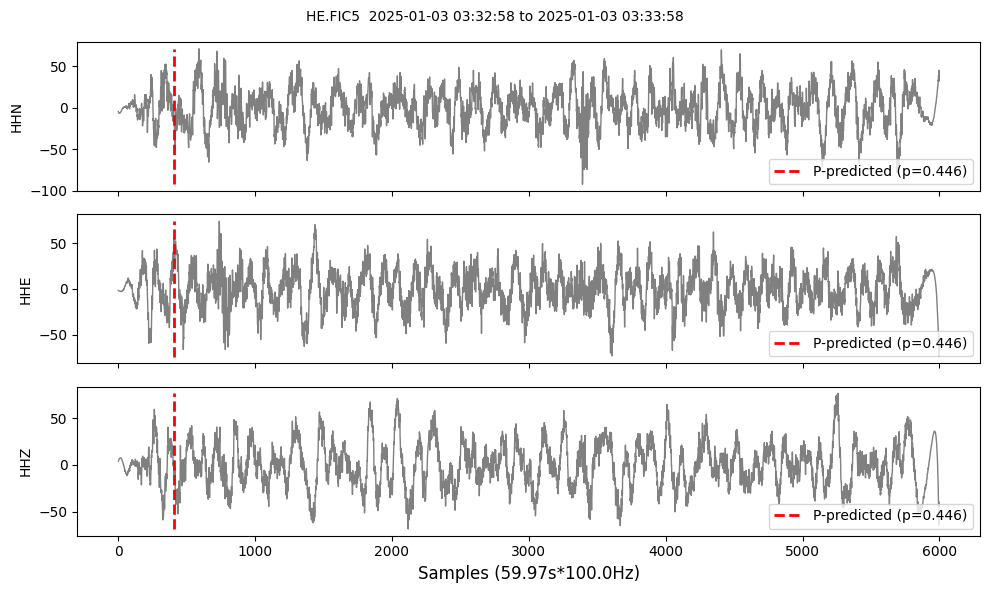

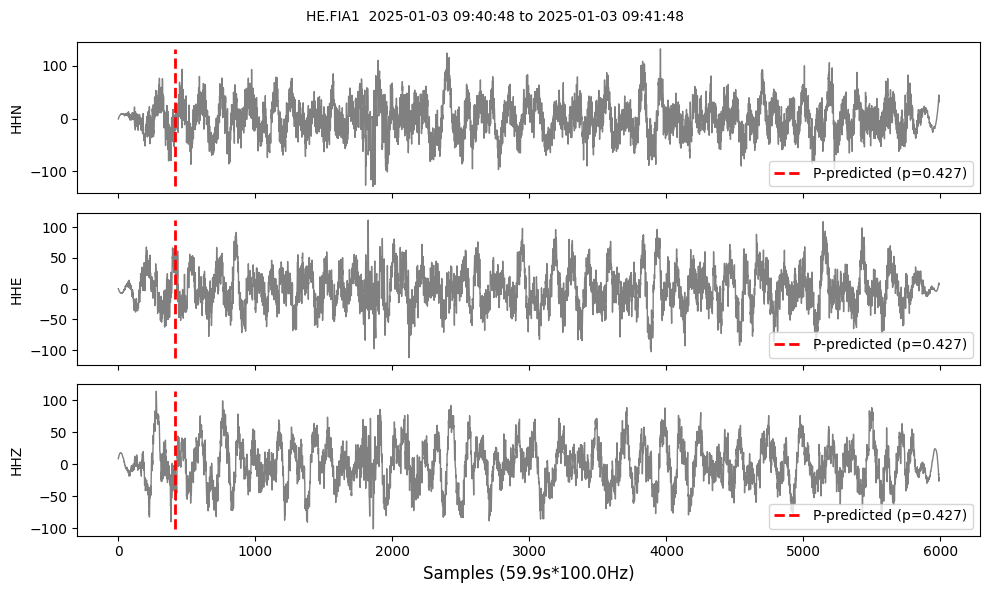

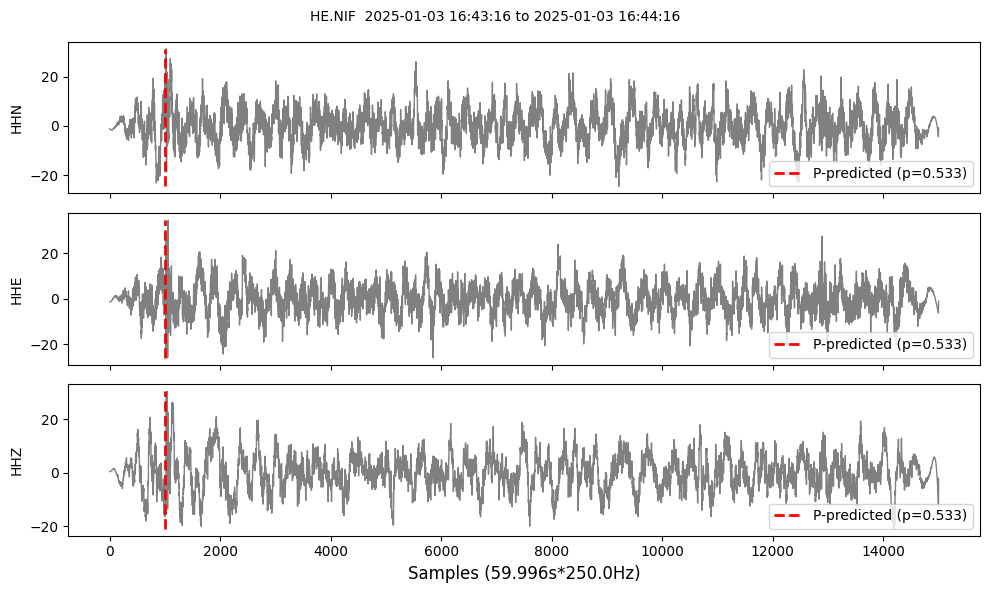

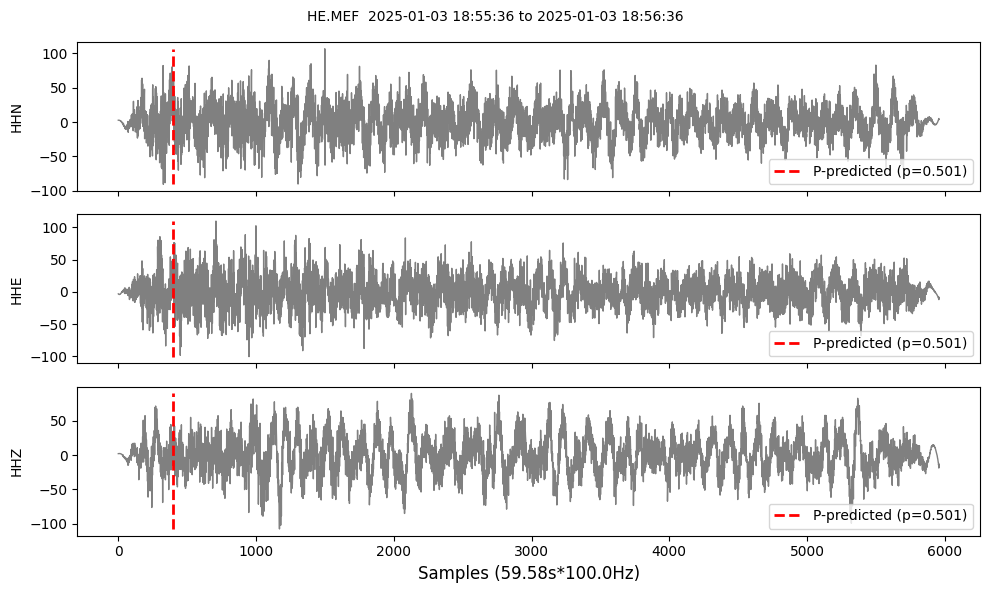

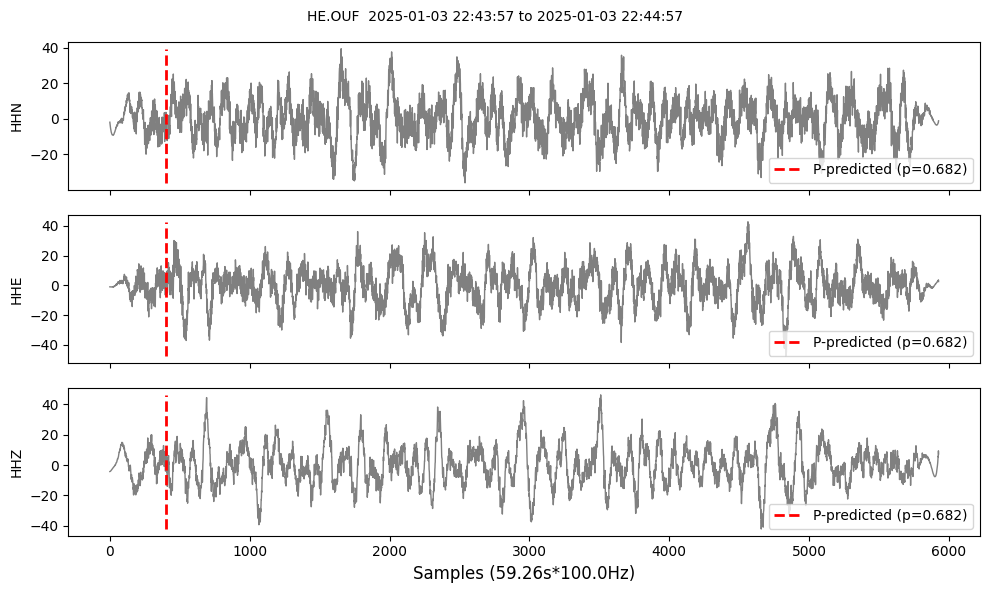

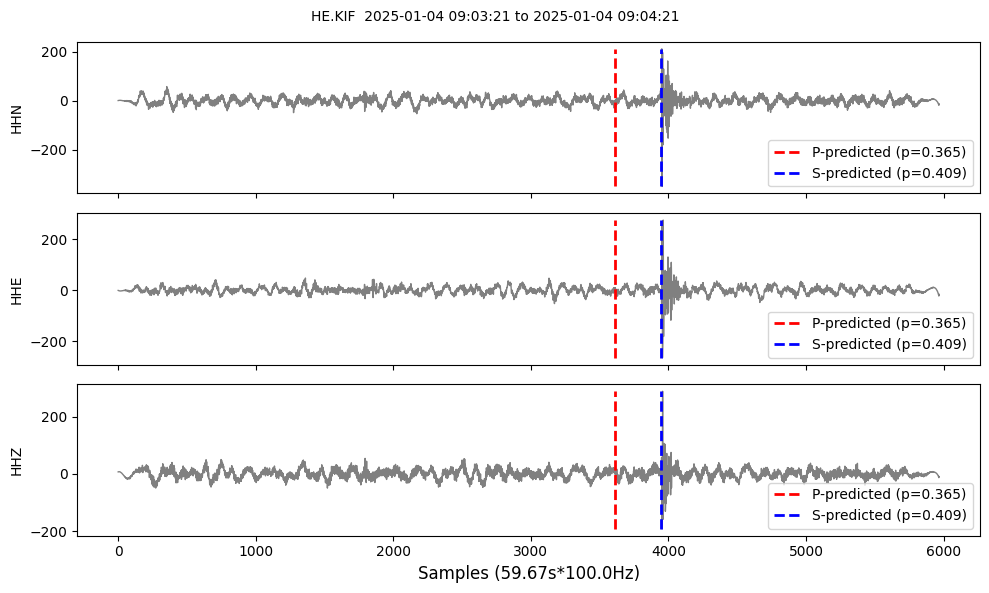

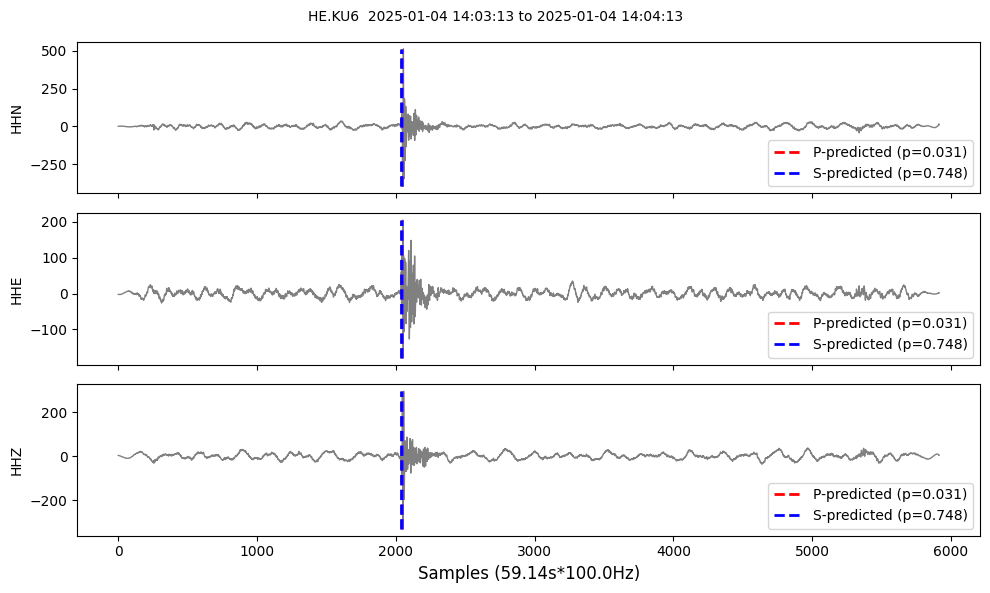

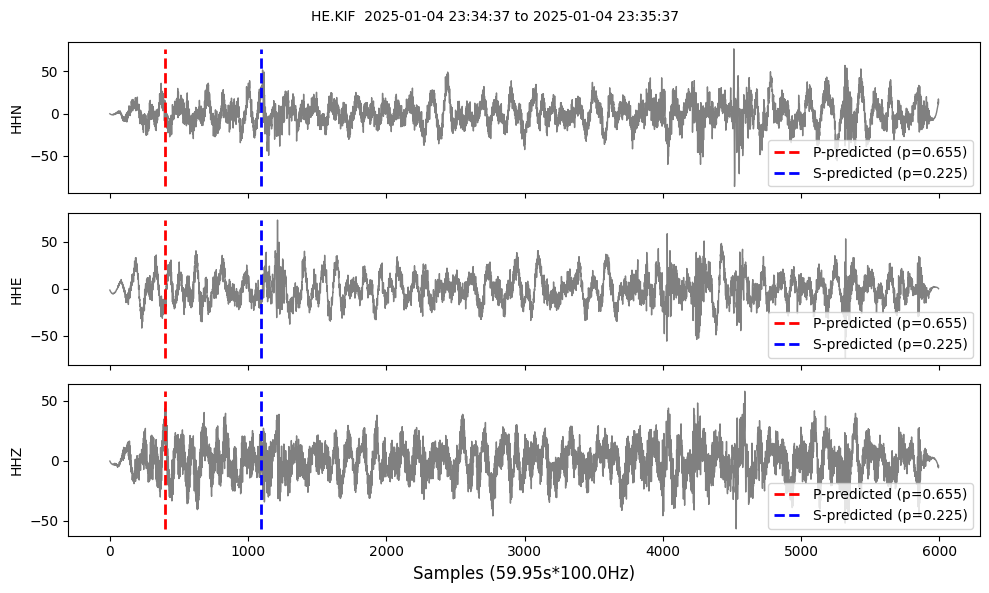

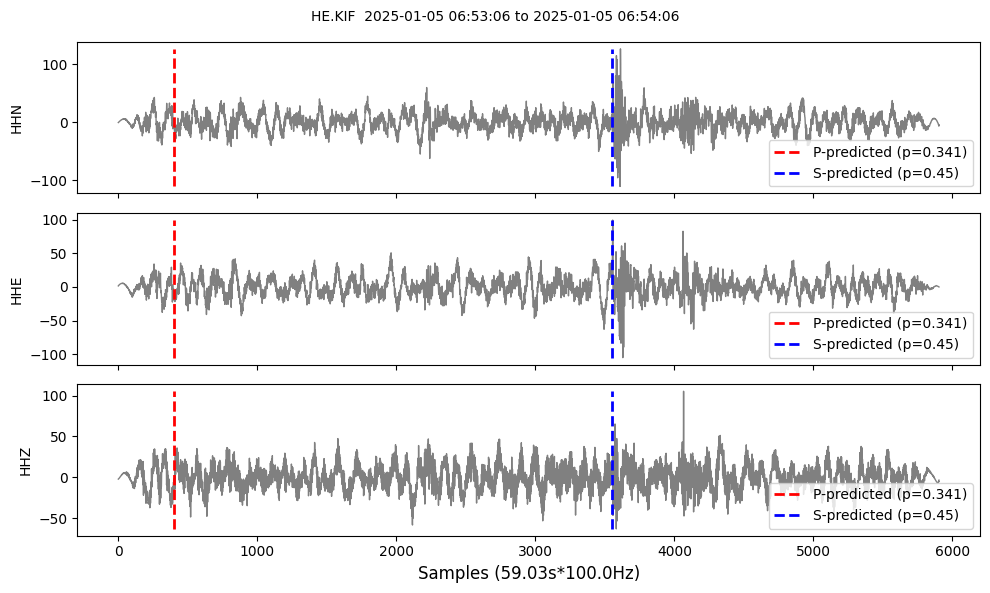

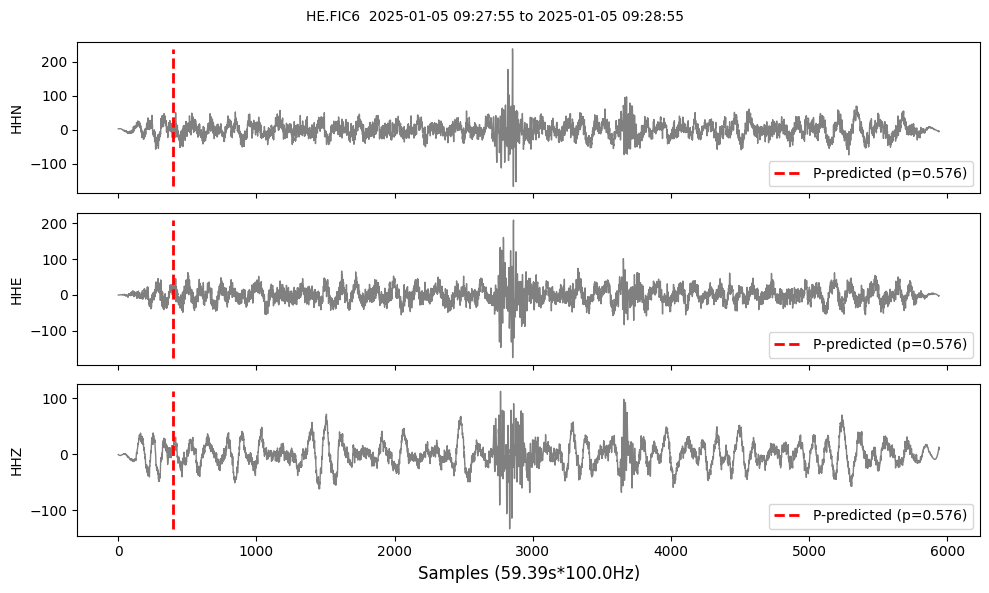

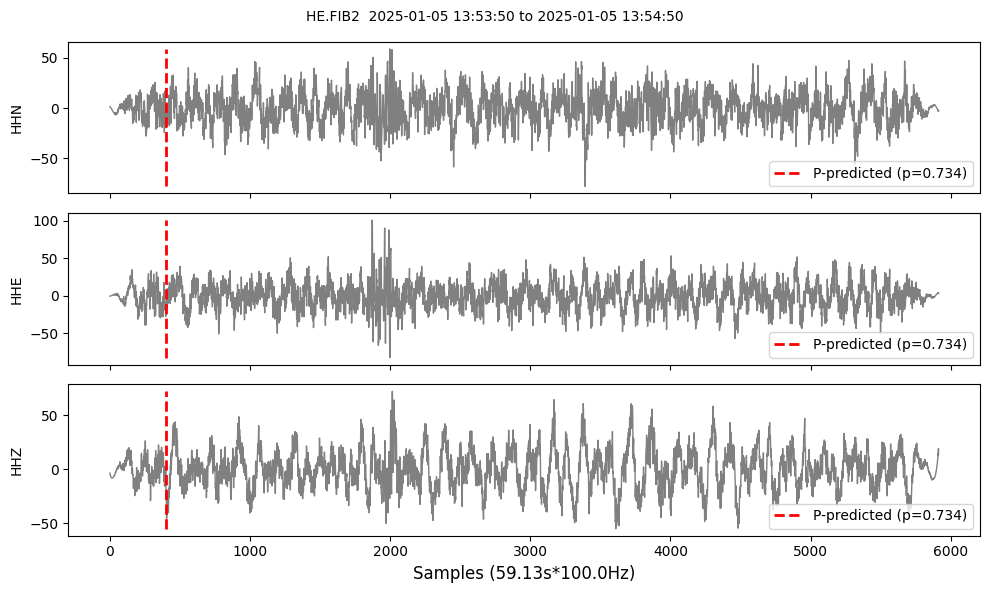

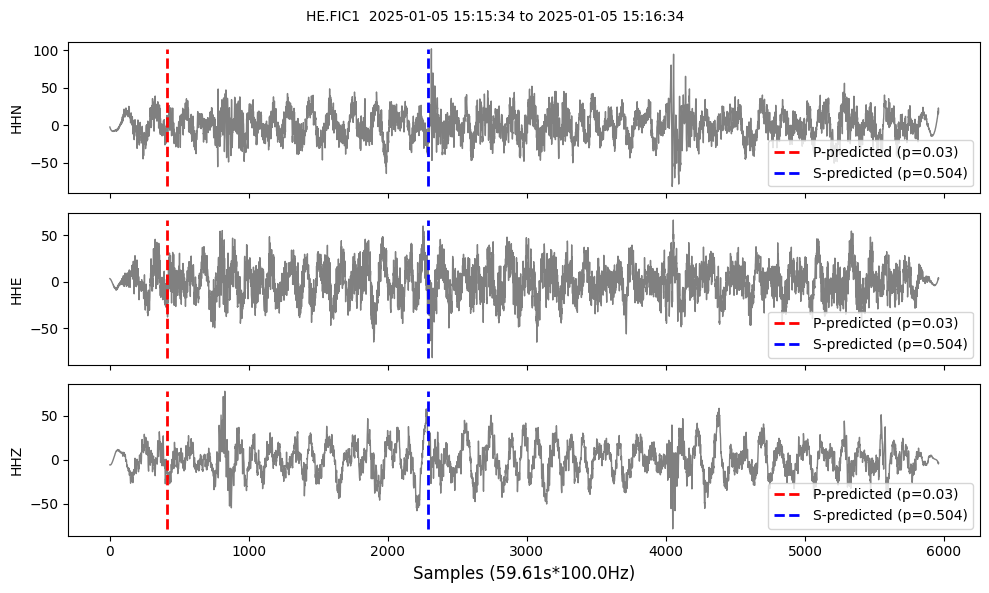

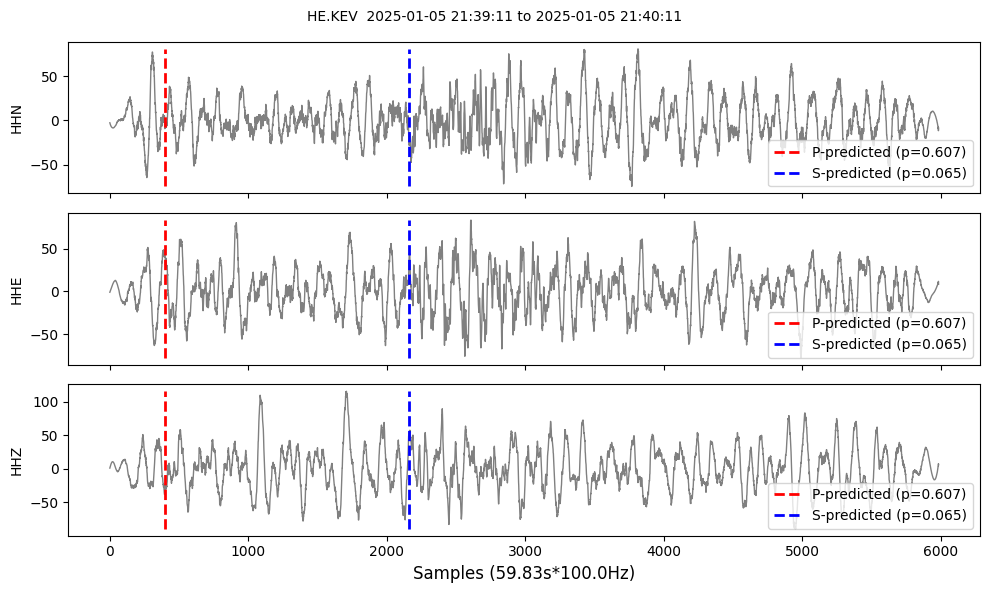

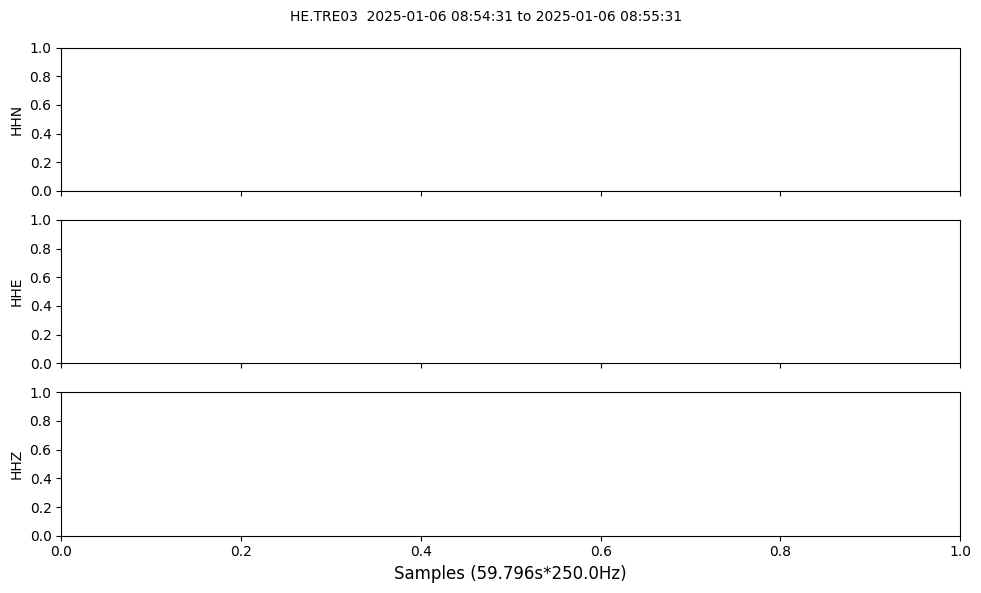

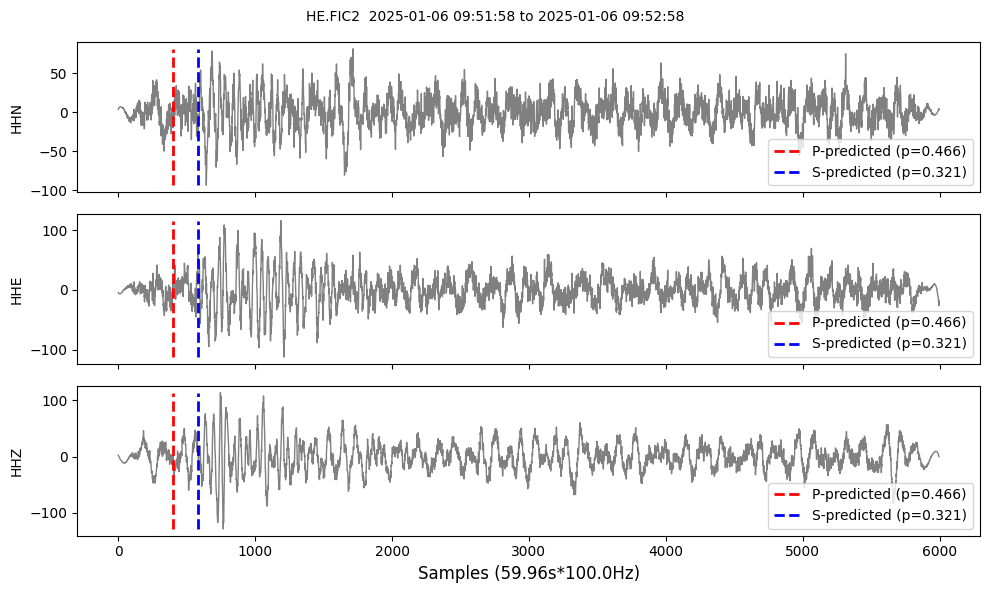

In [14]:
# Test plots
num_plots = 15
counter = 0

for _, row in df.head(2000).iterrows():
    plotted = plot_row(row, waveform_idx, 0.4)
    if plotted:
        counter += 1
        if counter >= num_plots:
            break